In [68]:
from torchvision import datasets, transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
import numpy as np
import torchvision
import torch

## Probability

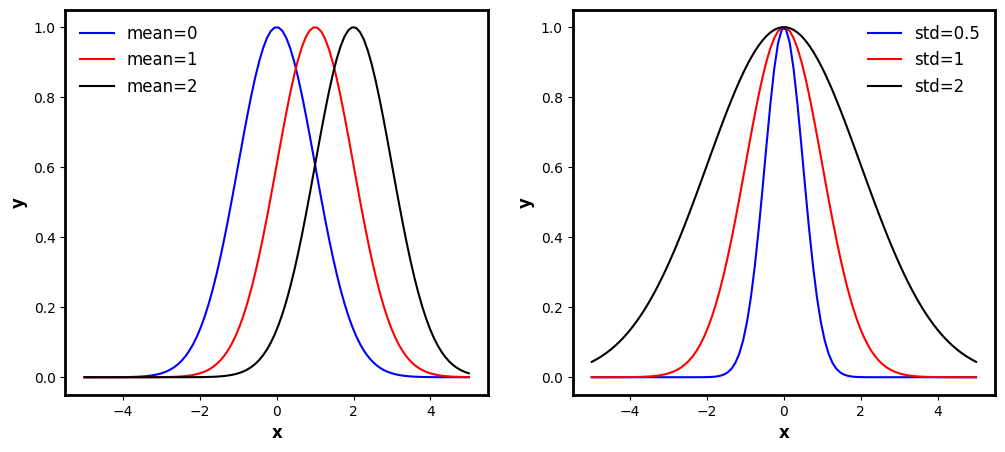

In [2]:
def normal(x, mean=0, std=1):
    return np.exp(-np.power(x - mean, 2.) / (2 * np.power(std, 2)))

x = np.linspace(-5, 5, 100)
y_mean_0 = normal(x)
y_mean_1 = normal(x, mean=1)
y_mean_2 = normal(x, mean=2)

y_std_1 = normal(x, std=0.5)
y_std_2 = normal(x, std=1)
y_std_3 = normal(x, std=2)

fig, ax = plt.subplots(1,2, figsize = (12, 5))
ax[0].plot(x, y_mean_0, label = "mean=0", color='blue')
ax[0].plot(x, y_mean_1, label = "mean=1", color = 'red')
ax[0].plot(x, y_mean_2, label = "mean=2", color = 'black')
ax[0].legend(frameon=False, fontsize = 12)
ax[0].set_xlabel("x", fontsize = 12, fontweight = "bold")
ax[0].set_ylabel("y", fontsize = 12, fontweight = "bold")

ax[1].plot(x, y_std_1, label = "std=0.5", color='blue')
ax[1].plot(x, y_std_2, label = "std=1", color = 'red')
ax[1].plot(x, y_std_3, label = "std=2", color = 'black')
ax[1].legend(frameon=False, fontsize = 12)
ax[1].set_xlabel("x", fontsize = 12, fontweight = "bold")
ax[1].set_ylabel("y", fontsize = 12, fontweight = "bold")

for ax in [ax[0], ax[1]]:
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.savefig("Figure_3.png")
plt.show()


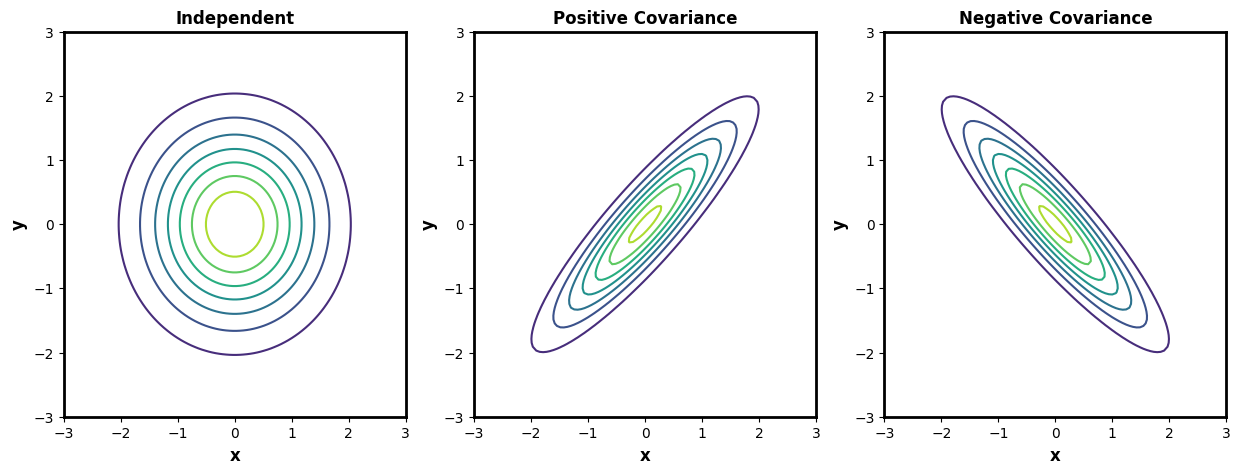

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def multivariate_normal(x, mean, cov):

    det =  np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    D = len(x)
    z =  1/ np.sqrt((2*np.pi) **D * det)
    y = z * np.exp((x-mean) @ inv @ (x-mean) / -2.0)
    return y

mu = np.array([0,0])
zero_cov = np.array([[1,0],
                [0,1]])


positive_cov = np.array([[1,0.9],
                [0.9,1]])

negative_cov = np.array([[1,-0.9],
                [-0.9,1]])

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X,Y = np.meshgrid(x, y)
Z_1 = np.zeros_like(X)
Z_2 = np.zeros_like(X)
Z_3 = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = np.array([X[i,j], Y[i,j]])
        Z_1[i,j] = multivariate_normal(x, mu, zero_cov)
        Z_2[i,j] = multivariate_normal(x, mu, positive_cov)
        Z_3[i,j] = multivariate_normal(x, mu, negative_cov)

fig, axs = plt.subplots(1,3, figsize = (15, 5))
axs[0].contour(X, Y, Z_1)
axs[0].set_xlabel("x", fontsize = 12, fontweight = "bold")
axs[0].set_ylabel("y", fontsize = 12, fontweight = "bold")
axs[0].set_title("Independent", fontsize = 12, fontweight = "bold")

axs[1].contour(X, Y, Z_2)
axs[1].set_xlabel("x", fontsize = 12, fontweight = "bold")
axs[1].set_ylabel("y", fontsize = 12, fontweight = "bold")
axs[1].set_title("Positive Covariance", fontsize = 12, fontweight = "bold")

axs[2].contour(X, Y, Z_3)
axs[2].set_xlabel("x", fontsize = 12, fontweight = "bold")
axs[2].set_ylabel("y", fontsize = 12, fontweight = "bold")
axs[2].set_title("Negative Covariance", fontsize = 12, fontweight = "bold")

for ax in axs:
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.savefig("Figure_4.png")
plt.show()


# Gaussian Mixture Model

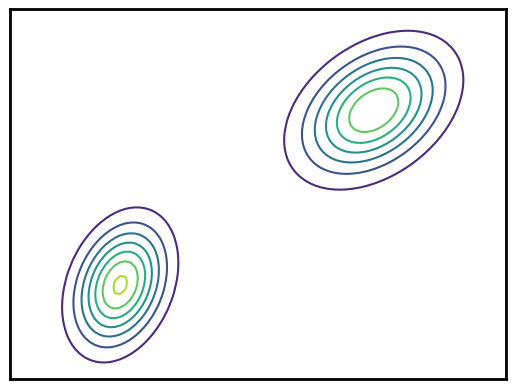

In [44]:
mus = np.array([[2, 54],
                [4.3, 80.0]])
covs = np.array([[[0.07, 0.44],
                  [0.44, 33.7]],

                 [[0.17, 0.94],
                  [0.94, 36.0]]])
ratios = np.array([0.4, 0.6])

def multivariate_normal(x, mu, cov):
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    d = len(x)
    z = 1 / np.sqrt((2 * np.pi) ** d * det)
    y = z * np.exp((x-mu).T @ inv @ (x-mu) / -2.0)
    return y

def gmm(x, phis, mus, covs):
    K = len(phis)
    y = 0
    for k in range(K):
        phi, mu, cov = phis[k], mus[k], covs[k]
        y += phi * multivariate_normal(x, mu, cov)
    return y

xs = np.linspace(1, 5.5, 100)
ys = np.linspace(40, 95, 100)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = np.array([X[i, j], Y[i, j]])
        Z[i, j] = gmm(x, ratios, mus, covs)

fig, ax = plt.subplots()
ax.contour(X, Y, Z)
ax.set_xticks([])
ax.set_yticks([])
for spines in ax.spines.values():
    spines.set_linewidth(2)
plt.show()

# EM algorithm

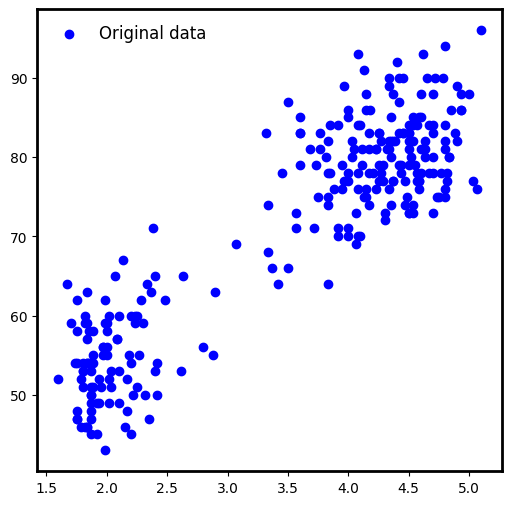

In [57]:
x1 = [3.6, 1.8, 3.333, 2.283, 4.533, 2.883, 4.7, 3.6, 1.95, 4.35, 1.833, 3.917, 4.2, 1.75, 4.7, 2.167, 1.75, 4.8, 1.6, 4.25, 1.8, 1.75, 3.45, 3.067, 4.533, 3.6, 1.967, 4.083, 3.85, 4.433, 4.3, 4.467, 3.367, 4.033, 3.833, 2.017, 1.867, 4.833, 1.833, 4.783, 4.35, 1.883, 4.567, 1.75, 4.533, 3.317, 3.833, 2.1, 4.633, 2.0, 4.8, 4.716, 1.833, 4.833, 1.733, 4.883, 3.717, 1.667, 4.567, 4.317, 2.233, 4.5, 1.75, 4.8, 1.817, 4.4, 4.167, 4.7, 2.067, 4.7, 4.033, 1.967, 4.5, 4.0, 1.983, 5.067, 2.017, 4.567, 3.883, 3.6, 4.133, 4.333, 4.1, 2.633, 4.067, 4.933, 3.95, 4.517, 2.167, 4.0, 2.2, 4.333, 1.867, 4.817, 1.833, 4.3, 4.667, 3.75, 1.867, 4.9, 2.483, 4.367, 2.1, 4.5, 4.05, 1.867, 4.7, 1.783, 4.85, 3.683, 4.733, 2.3, 4.9, 4.417, 1.7, 4.633, 2.317, 4.6, 1.817, 4.417, 2.617, 4.067, 4.25, 1.967, 4.6, 3.767, 1.917, 4.5, 2.267, 4.65, 1.867, 4.167, 2.8, 4.333, 1.833, 4.383, 1.883, 4.933, 2.033, 3.733, 4.233, 2.233, 4.533, 4.817, 4.333, 1.983, 4.633, 2.017, 5.1, 1.8, 5.033, 4.0, 2.4, 4.6, 3.567, 4.0, 4.5, 4.083, 1.8, 3.967, 2.2, 4.15, 2.0, 3.833, 3.5, 4.583, 2.367, 5.0, 1.933, 4.617, 1.917, 2.083, 4.583, 3.333, 4.167, 4.333, 4.5, 2.417, 4.0, 4.167, 1.883, 4.583, 4.25, 3.767, 2.033, 4.433, 4.083, 1.833, 4.417, 2.183, 4.8, 1.833, 4.8, 4.1, 3.966, 4.233, 3.5, 4.366, 2.25, 4.667, 2.1, 4.35, 4.133, 1.867, 4.6, 1.783, 4.367, 3.85, 1.933, 4.5, 2.383, 4.7, 1.867, 3.833, 3.417, 4.233, 2.4, 4.8, 2.0, 4.15, 1.867, 4.267, 1.75, 4.483, 4.0, 4.117, 4.083, 4.267, 3.917, 4.55, 4.083, 2.417, 4.183, 2.217, 4.45, 1.883, 1.85, 4.283, 3.95, 2.333, 4.15, 2.35, 4.933, 2.9, 4.583, 3.833, 2.083, 4.367, 2.133, 4.35, 2.2, 4.45, 3.567, 4.5, 4.15, 3.817, 3.917, 4.45, 2.0, 4.283, 4.767, 4.533, 1.85, 4.25, 1.983, 2.25, 4.75, 4.117, 2.15, 4.417, 1.817, 4.467]
x2 = [79.0, 54.0, 74.0, 62.0, 85.0, 55.0, 88.0, 85.0, 51.0, 85.0, 54.0, 84.0, 78.0, 47.0, 83.0, 52.0, 62.0, 84.0, 52.0, 79.0, 51.0, 47.0, 78.0, 69.0, 74.0, 83.0, 55.0, 76.0, 78.0, 79.0, 73.0, 77.0, 66.0, 80.0, 74.0, 52.0, 48.0, 80.0, 59.0, 90.0, 80.0, 58.0, 84.0, 58.0, 73.0, 83.0, 64.0, 53.0, 82.0, 59.0, 75.0, 90.0, 54.0, 80.0, 54.0, 83.0, 71.0, 64.0, 77.0, 81.0, 59.0, 84.0, 48.0, 82.0, 60.0, 92.0, 78.0, 78.0, 65.0, 73.0, 82.0, 56.0, 79.0, 71.0, 62.0, 76.0, 60.0, 78.0, 76.0, 83.0, 75.0, 82.0, 70.0, 65.0, 73.0, 88.0, 76.0, 80.0, 48.0, 86.0, 60.0, 90.0, 50.0, 78.0, 63.0, 72.0, 84.0, 75.0, 51.0, 82.0, 62.0, 88.0, 49.0, 83.0, 81.0, 47.0, 84.0, 52.0, 86.0, 81.0, 75.0, 59.0, 89.0, 79.0, 59.0, 81.0, 50.0, 85.0, 59.0, 87.0, 53.0, 69.0, 77.0, 56.0, 88.0, 81.0, 45.0, 82.0, 55.0, 90.0, 45.0, 83.0, 56.0, 89.0, 46.0, 82.0, 51.0, 86.0, 53.0, 79.0, 81.0, 60.0, 82.0, 77.0, 76.0, 59.0, 80.0, 49.0, 96.0, 53.0, 77.0, 77.0, 65.0, 81.0, 71.0, 70.0, 81.0, 93.0, 53.0, 89.0, 45.0, 86.0, 58.0, 78.0, 66.0, 76.0, 63.0, 88.0, 52.0, 93.0, 49.0, 57.0, 77.0, 68.0, 81.0, 81.0, 73.0, 50.0, 85.0, 74.0, 55.0, 77.0, 83.0, 83.0, 51.0, 78.0, 84.0, 46.0, 83.0, 55.0, 81.0, 57.0, 76.0, 84.0, 77.0, 81.0, 87.0, 77.0, 51.0, 78.0, 60.0, 82.0, 91.0, 53.0, 78.0, 46.0, 77.0, 84.0, 49.0, 83.0, 71.0, 80.0, 49.0, 75.0, 64.0, 76.0, 53.0, 94.0, 55.0, 76.0, 50.0, 82.0, 54.0, 75.0, 78.0, 79.0, 78.0, 78.0, 70.0, 79.0, 70.0, 54.0, 86.0, 50.0, 90.0, 54.0, 54.0, 77.0, 79.0, 64.0, 75.0, 47.0, 86.0, 63.0, 85.0, 82.0, 57.0, 82.0, 67.0, 74.0, 54.0, 83.0, 73.0, 73.0, 88.0, 80.0, 71.0, 83.0, 56.0, 79.0, 78.0, 84.0, 58.0, 83.0, 43.0, 60.0, 75.0, 81.0, 46.0, 90.0, 46.0, 74.0]

fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(x1, x2, label ="Original data", color = "blue")
ax.legend(frameon=False, fontsize=12)
for spines in ax.spines.values():
    spines.set_linewidth(2)
plt.savefig("Original_data.png", dpi=300)
plt.show()

iter: [0/100], likelihood: -4.429742277595774
iter: [1/100], likelihood: -4.371952286283529
iter: [2/100], likelihood: -4.320818738422184
iter: [3/100], likelihood: -4.263548026592555
iter: [4/100], likelihood: -4.213753398476411
iter: [5/100], likelihood: -4.173798652207801
iter: [6/100], likelihood: -4.156547060756423
iter: [7/100], likelihood: -4.155421812306584
iter: [8/100], likelihood: -4.1553826766802


C:\Users\hansu\AppData\Local\Temp\ipykernel_6476\26739104.py:93: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


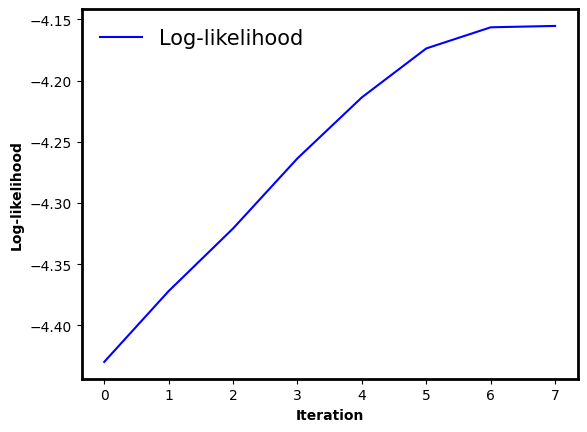

In [ ]:
## Parameter Initialization

phis = np.array([0.5, 0.5])
mus = np.array([[0.0, 50.1], [0.0, 100.0]])
covs = np.array([np.eye(2), np.eye(2)])
xs = np.array([x1, x2]).T # shape = (272,2)
K = len(phis)
N = len(x1)
MAX_ITERS = 100
THRESHOLD = 1e-4


def multivariate_normal(x, mu, cov):
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    d = len(x)
    z = 1 / np.sqrt((2 * np.pi) ** d * det)
    y = z * np.exp((x-mu).T @ inv @ (x-mu) / -2.0)
    return y

def gmm(x, phis, mus, covs):
    K = len(phis)
    y = 0
    for k in range(K):
        phi, mu, cov = phis[k], mus[k], covs[k]
        y += phi * multivariate_normal(x, mu, cov)
    return y

def likelihood(xs, phis, mus, covs):
    eps = 1e-8
    L = 0
    N = len(xs)
    for x in xs:
        y = gmm(x, phis, mus, covs)
        L += np.log(y + eps)
    return L / N

current_likelihood = likelihood(xs, phis, mus, covs)
history = {
    "iter": [],
    "likelihood": []
}
for iter in range(MAX_ITERS):

    # E-step
    qs = np.zeros((N, K))
    for i in range(N):
        x = xs[i]
        for j in range(K):
            phi, mu, cov = phis[j], mus[j], covs[j]
            qs[i, j] = phi * multivariate_normal(x, mu, cov)
        
        qs[i] /= gmm(x, phis, mus, covs)

    # M-step
    qs_sum = qs.sum(axis=0)
    for j in range(K):

        # phis
        phis[j] = qs_sum[j] / N

        # mus
        c = 0
        for i in range(N):
            c += qs[i, j] * xs[i]
        mus[j] = c / qs_sum[j]

        # covs
        c = 0
        for i in range(N):
            z = xs[i] - mus[j]
            z = z[:, np.newaxis]
            c += qs[i, j] * z @ z.T
        covs[j] = c / qs_sum[j]
    

    # Check and terminate
    print(f"Iteration: [{iter}/{MAX_ITERS}], likelihood: {likelihood(xs, phis, mus, covs)}")
    next_likelihood = likelihood(xs, phis, mus, covs)
    if iter > 0 and np.abs(next_likelihood - current_likelihood) < THRESHOLD:
        break
    current_likelihood = next_likelihood
    history["iter"].append(iter)
    history["likelihood"].append(current_likelihood)

fig, ax = plt.subplots()
ax.plot(history["iter"], history["likelihood"], color = "blue", label = "Log-likelihood")
ax.set_xlabel("Iteration", fontweight = "bold")
ax.set_ylabel("Log-likelihood", fontweight = "bold")
plt.legend(frameon=False, fontsize = 15)
for spines in ax.spines.values():
    spines.set_linewidth(2)
fig.show()

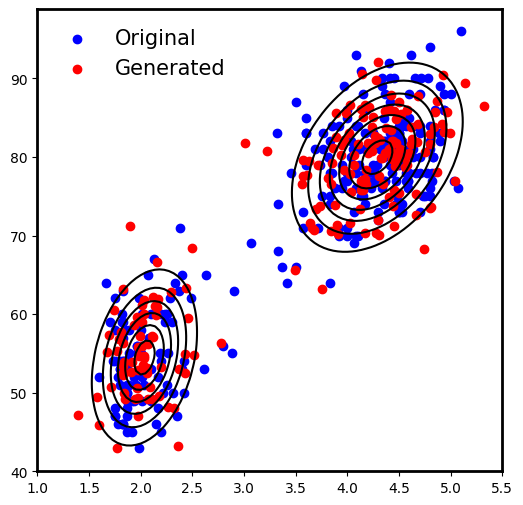

In [56]:
# Generate new data
N = 200
new_xs = np.zeros((N, 2))
for i in range(N):
    k = np.random.choice(2, p=phis)
    mu, cov = mus[k], covs[k]
    new_xs[i] = np.random.multivariate_normal(mu, cov)

xs = np.linspace(1, 5.5, 100)
ys = np.linspace(40, 95, 100)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = np.array([X[i, j], Y[i, j]])
        Z[i, j] = gmm(x, phis, mus, covs)



fig, ax = plt.subplots(figsize = (6, 6))
ax.scatter(x1, x2, color = 'blue', label = 'Original')
ax.scatter(new_xs[:, 0], new_xs[:, 1], color = 'red', label = 'Generated')
ax.contour(X, Y, Z, colors = 'black')
ax.legend(frameon = False, fontsize = 15)
for spines in ax.spines.values():
    spines.set_linewidth(2)
plt.savefig("Original_and_generated_data.png", dpi=300)
plt.show()

## VAE architecture

In [61]:
input_dim = 784
hidden_dim = 200
latent_dim =20
epochs = 20
learning_rate = 3e-4
batch_size = 16

class VAE_Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE_Encoder, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear_mu = nn.Linear(hidden_dim, latent_dim)
        self.linear_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.linear1(x)
        h = F.relu(h)

        mu = self.linear_mu(h)
        logvar = self.linear_logvar(h)
        sigma = torch.exp(0.5 * logvar)

        eps = torch.randn_like(sigma)
        z = mu + sigma * eps

        return z, mu, sigma

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = self.linear1(z)
        h = F.relu(h)
        h = self.linear2(h)
        x_hat = F.sigmoid(h)
        return x_hat


class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = VAE_Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)
    
    def get_loss(self, x):

        z, mu, sigma = self.encoder(x)
        x_hat = self.decoder(z)

        batch_size = len(x)
        L1 = F.mse_loss(x_hat, x, reduction='sum')
        L2 = -1 * torch.sum(1 + torch.log(sigma **2) - mu **2 - sigma **2)
        return (L1 + L2) / batch_size



transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(torch.flatten)])
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("Data loaded")

model = VAE(input_dim, hidden_dim, latent_dim)


optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []

for epoch in range(epochs):
    loss_sum = 0.0
    cnt = 0
    for i, (x, _) in enumerate(data_loader):
        optimizer.zero_grad()
        loss = model.get_loss(x)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        cnt += 1

    loss_avg = loss_sum / cnt
    loss_history.append(loss_avg)

    print(f'Epoch {epoch+1}/{epochs}, VAE Loss: {loss_avg}')



Data loaded
Epoch 1/20, VAE Loss: 50.73208934936523
Epoch 2/20, VAE Loss: 44.19914812113444
Epoch 3/20, VAE Loss: 42.50357007344564
Epoch 4/20, VAE Loss: 41.48242165578206
Epoch 5/20, VAE Loss: 40.904201508585615
Epoch 6/20, VAE Loss: 40.46864321085612
Epoch 7/20, VAE Loss: 40.17786168365478
Epoch 8/20, VAE Loss: 39.98509867960612
Epoch 9/20, VAE Loss: 39.762242021687825
Epoch 10/20, VAE Loss: 39.649485506184895
Epoch 11/20, VAE Loss: 39.467035913594565
Epoch 12/20, VAE Loss: 39.37038542327881
Epoch 13/20, VAE Loss: 39.31534722035726
Epoch 14/20, VAE Loss: 39.21350258941651
Epoch 15/20, VAE Loss: 39.10636982421875
Epoch 16/20, VAE Loss: 39.059205737813315
Epoch 17/20, VAE Loss: 38.97212126719157
Epoch 18/20, VAE Loss: 38.90905984751384
Epoch 19/20, VAE Loss: 38.82018324686686
Epoch 20/20, VAE Loss: 38.79044642944336


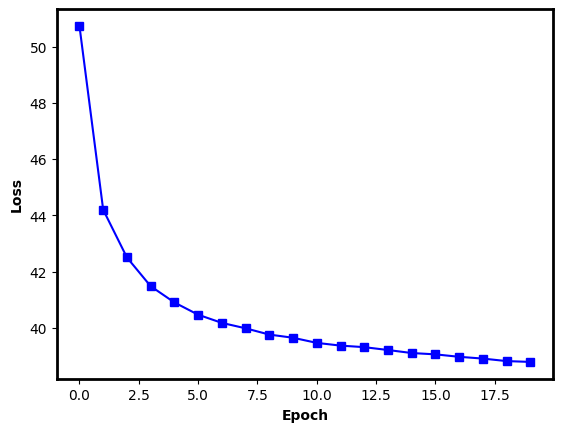

In [66]:
fig, ax = plt.subplots()
ax.plot(loss_history, 's-', color='blue')
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Loss', fontweight='bold')
for spines in ax.spines.values():
    spines.set_linewidth(2)
plt.show()

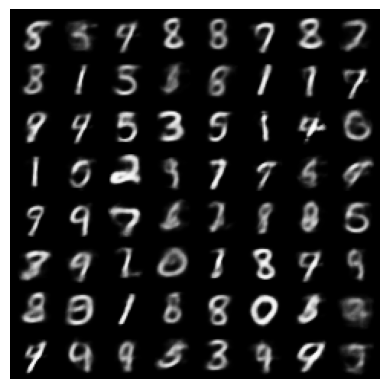

In [73]:
with torch.no_grad():
    sample_size = 64
    z = torch.randn(sample_size, latent_dim)
    x = model.decoder(z)
    generated_imgs = x.view(sample_size, 1, 28, 28)

grid_img = torchvision.utils.make_grid(generated_imgs, nrow=8, padding=2, normalize=True)

plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.show()